# Business Problem
Swiggy processes millions of food-delivery journeys across hundreds of cities every month. Accurate Estimated Time of Arrival (ETA) at order placement and during delivery is core to the customer experience — it affects conversion, cancellations, ratings, and retention. Today’s ETA accuracy suffers from many sources of uncertainty: highly variable traffic patterns, weather events, restaurant preparation variability, rider behaviour and skill, order batching/multiple deliveries, and city-specific operational constraints. Inaccurate ETAs cause:
* Reduced customer trust and lower repeat orders.
* Increased cancellations and refund costs.
* Higher support volume and operational interventions.
* Sub-optimal rider allocation and increased rider idle or overtime costs.

## Problem Statement
Swiggy’s objective is to predict the delivery time (minutes) per order at the moment of order placement (and update it dynamically), with business-grade accuracy and uncertainty estimates so the platform can
 (a) show reliable ETAs to customers
 (b) optimize rider allocation.
Build a production-ready, scalable Machine Learning system that predicts per-order delivery time (in minutes) using real-time and historical features (order, rider, restaurant, geospatial, traffic, weather, and temporal signals).

# Dataset Overview
* Rider_id:- Unique identifier for each delivery partner.
* Age       :- Age of the delivery partner.
* Ratings                :-  Average customer rating of the rider.
* vehicle_condition:-Condition of the rider’s vehicle.(0 => poor ,1=>Average, 2=>Good)
* Type_of_vehicle   :-Vehicle used for delivery (motorcycle, scooter, etc.).
* Type_of_order      :-Type of food ordered (snack, meal, drinks, buffet).
* multiple_deliveries:-Number of deliveries assigned to the rider in a single trip.
* pickup_time_minutes:-Time taken by the restaurant to prepare the order.
* restaurant_longitude:-Geographic coordinates of the restaurant.
* delivery_longitude:- Geographic coordinates of the customer’s delivery location.
* Is_weekend             :-Indicates whether the order was placed on a weekend.
* Order_time_hour    :-Hour when the order was placed (0–23).
* order_time_of_day:- Time bucket (morning, afternoon, evening, night).
* Weather                   :-Weather condition during delivery (sunny, cloudy, fog, stormy, sandstorms).
* Traffic                      :-Traffic condition during delivery.
* Festival                    :-Indicates whether the order was placed on a festival day.
* City_type                 :-Classification of city (urban, metropolitan).
* City_name               :-Name/code of the city (BANG, HYD, CHEN, etc.).
* Time_taken              :- Actual time taken (in minutes) to complete the delivery.
* Distance                   :-Distance (in km) between restaurant and delivery location.
* Order_date               :-Date when the order was placed.
* Order_day                :-Day of the month.
* Order_month           :-Month of the order.
* order_day_of_week:-Day of the week (Monday–Sunday).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\Projects\Project 2\swiggy.csv")
df.sample(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
26698,RANCHIRES13DEL01,25.0,4.9,23.374989,85.335486,23.444989,85.405486,2022-03-29,sunny,medium,...,15,RANCHI,29,3,tuesday,0,5.0,17.0,evening,10.564406
4431,MYSRES11DEL01,31.0,3.5,12.323225,76.630028,12.393225,76.700028,2022-03-08,windy,jam,...,32,MYS,8,3,tuesday,0,10.0,21.0,night,10.880951
16406,INDORES17DEL02,32.0,5.0,22.761226,75.887522,22.781226,75.907522,2022-03-15,cloudy,low,...,18,INDO,15,3,tuesday,0,5.0,9.0,morning,3.024985
10789,KNPRES03DEL01,26.0,4.7,26.469003,80.316344,26.579003,80.426344,2022-02-14,sandstorms,jam,...,16,KNP,14,2,monday,0,15.0,21.0,night,16.412810
42389,RANCHIRES19DEL02,21.0,4.6,23.333017,85.317200,23.463017,85.447200,2022-03-31,windy,low,...,11,RANCHI,31,3,thursday,0,5.0,22.0,night,19.620419


# 2. Exploratory Data Analysis

### Dataset OverView

In [3]:
df.shape # 45502 rows and 26 columns

(45502, 26)

In [4]:
df.head(1)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149


In [5]:
df.info()  # help in understanding the datatype and no of non null values

<class 'pandas.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  str    
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  str    
 8   weather               44977 non-null  str    
 9   traffic               44992 non-null  str    
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  str    
 12  type_of_vehicle       45502 non-null  str    
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  str    
 15  city_type             44304 no

### Checking missing values

In [6]:
print("Missing Values \n",df.isnull().sum())
print("-------------------------------------------------------")
print("Missing Values in precentage \n", (df.isnull().sum()/len(df))*100)

## helps in understanding how much data is missing and if it is huge/less

Missing Values 
 rider_id                   0
age                     1854
ratings                 1908
restaurant_latitude     3630
restaurant_longitude    3630
delivery_latitude       3630
delivery_longitude      3630
order_date                 0
weather                  525
traffic                  510
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries      993
festival                 228
city_type               1198
time_taken                 0
city_name                  0
order_day                  0
order_month                0
order_day_of_week          0
is_weekend                 0
pickup_time_minutes     1640
order_time_hour         1640
order_time_of_day          0
distance                3630
dtype: int64
-------------------------------------------------------
Missing Values in precentage 
 rider_id                0.000000
age                     4.074546
ratings                 4.193222
restaurant_latitude     7.9776

<Axes: ylabel='time_taken'>

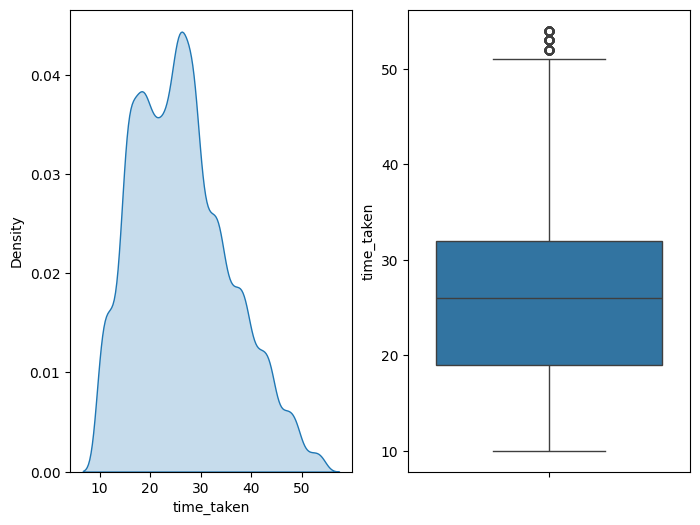

In [7]:
# Target Distribution

plt.figure(figsize=(8,6))

plt.subplot(1,2,1)
sns.kdeplot(df["time_taken"],fill=True)

plt.subplot(1,2,2)
sns.boxplot(df["time_taken"])

## most delivereis are in between 15 to 35 mins
## right skew Distribution and contains outliers like extreme delays
## two peaks in kde means divided into two sub large groups

### Univariate Analysis

#### Numerical

<Axes: ylabel='multiple_deliveries'>

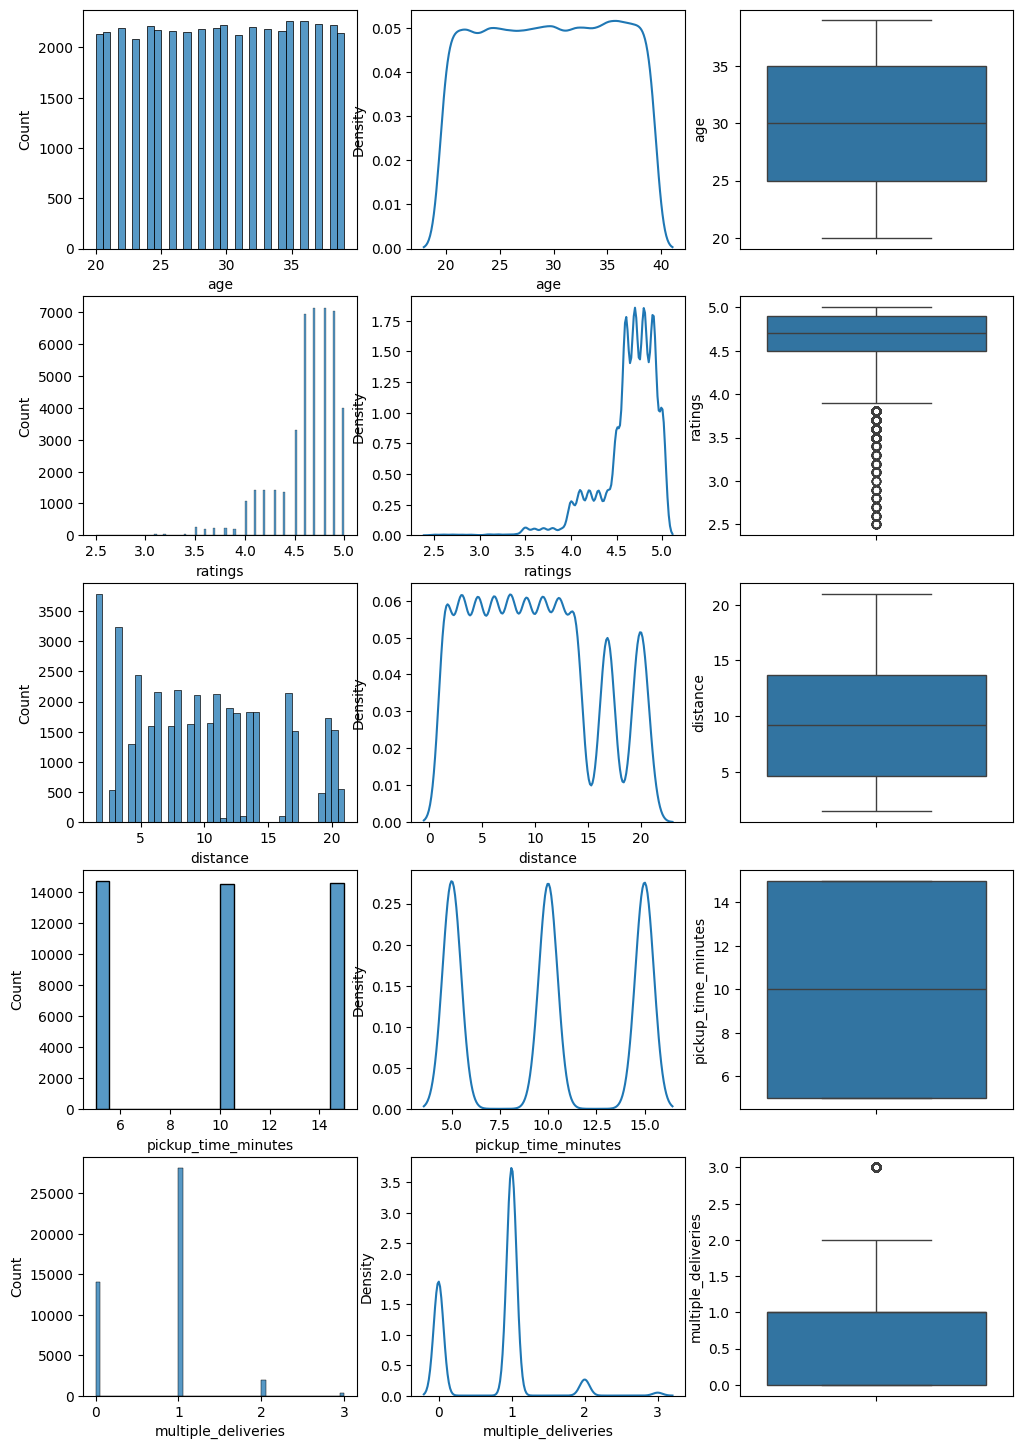

In [8]:
plt.figure(figsize=(12,18))

plt.subplot(5,3,1)
sns.histplot(df["age"])
plt.subplot(5,3,2)
sns.kdeplot(df["age"])
plt.subplot(5,3,3)
sns.boxplot(df["age"])

plt.subplot(5,3,4)
sns.histplot(df["ratings"])
plt.subplot(5,3,5)
sns.kdeplot(df["ratings"])
plt.subplot(5,3,6)
sns.boxplot(df["ratings"])

plt.subplot(5,3,7)
sns.histplot(df["distance"])
plt.subplot(5,3,8)
sns.kdeplot(df["distance"])
plt.subplot(5,3,9)
sns.boxplot(df["distance"])

plt.subplot(5,3,10)
sns.histplot(df["pickup_time_minutes"])
plt.subplot(5,3,11)
sns.kdeplot(df["pickup_time_minutes"])
plt.subplot(5,3,12)
sns.boxplot(df["pickup_time_minutes"])

plt.subplot(5,3,13)
sns.histplot(df["multiple_deliveries"])
plt.subplot(5,3,14)
sns.kdeplot(df["multiple_deliveries"])
plt.subplot(5,3,15)
sns.boxplot(df["multiple_deliveries"])

#### categorical

([<matplotlib.patches.Wedge at 0x1d9512f3750>,
 [Text(-1.0978840750086092, 0.06819499866185577, 'no'),
  Text(1.097884097229302, -0.06819464092581301, 'yes')],
 [Text(-0.598845859095605, 0.03719727199737587, '98.0%'),
  Text(0.5988458712159829, -0.03719707686862527, '2.0%')])

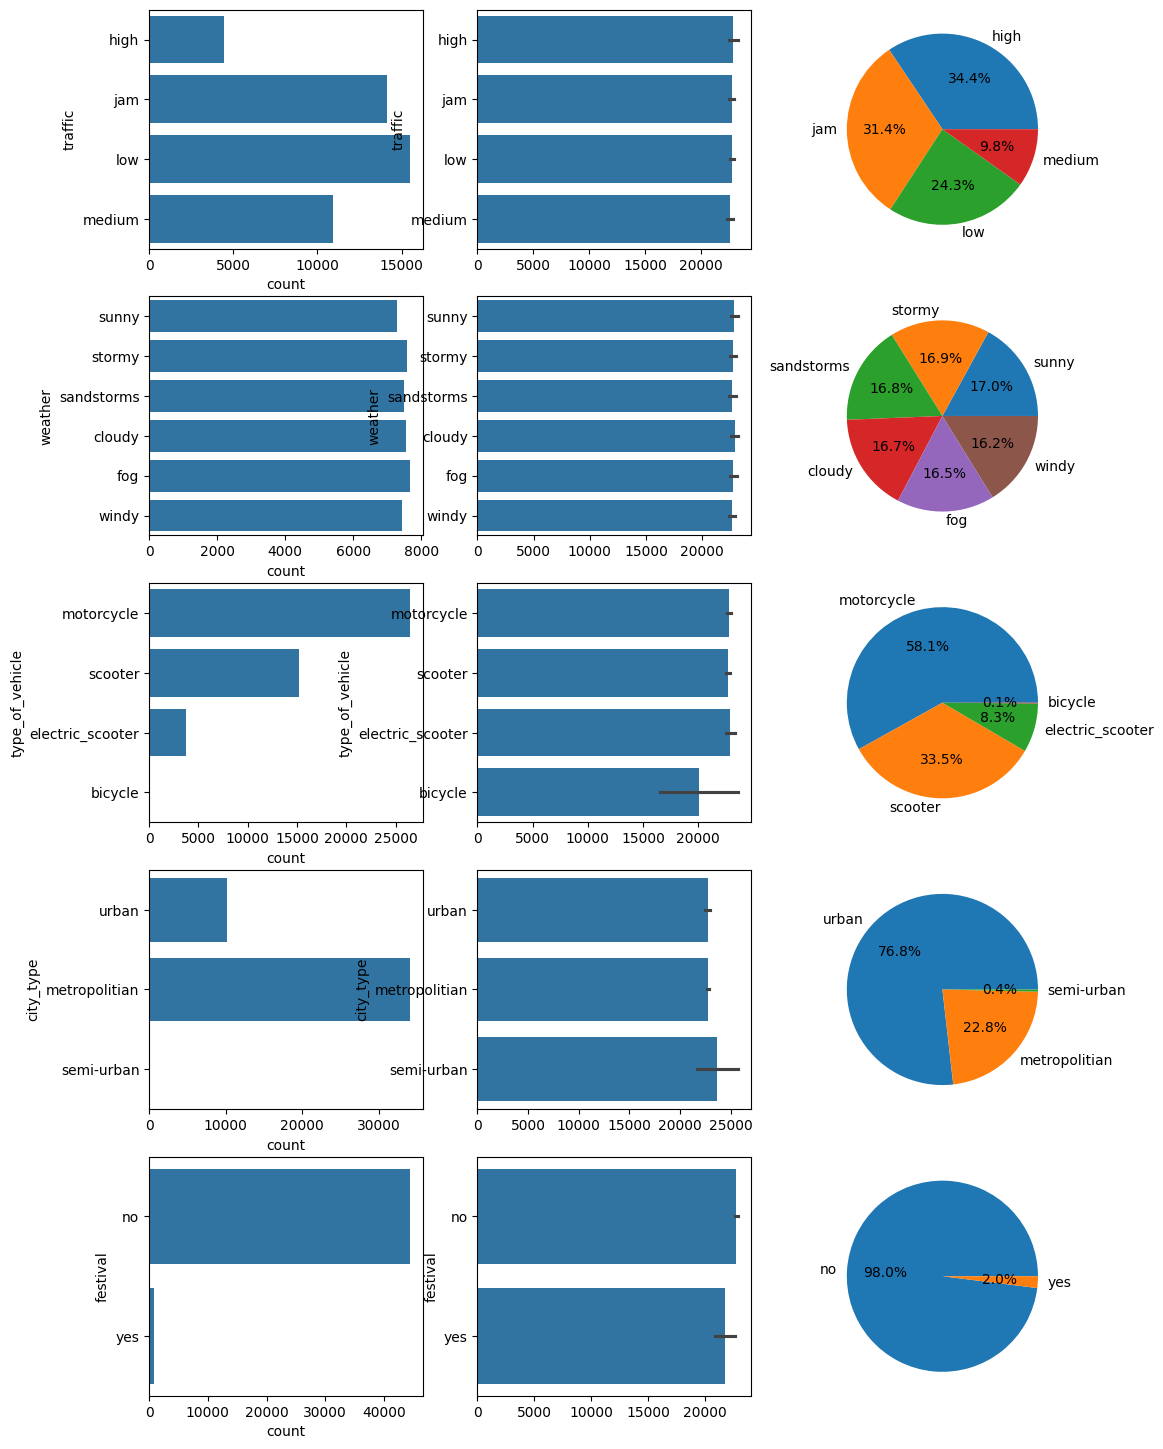

In [9]:
plt.figure(figsize=(12,18))

plt.subplot(5,3,1)
sns.countplot(df["traffic"])
plt.subplot(5,3,2)
sns.barplot(df["traffic"])
plt.subplot(5,3,3)
plt.pie(df["traffic"].value_counts(),autopct='%1.1f%%',labels=df["traffic"].dropna().unique())

plt.subplot(5,3,4)
sns.countplot(df["weather"])
plt.subplot(5,3,5)
sns.barplot(df["weather"])
plt.subplot(5,3,6)
plt.pie(df["weather"].value_counts(),autopct='%1.1f%%',labels=df["weather"].dropna().unique())

plt.subplot(5,3,7)
sns.countplot(df["type_of_vehicle"])
plt.subplot(5,3,8)
sns.barplot(df["type_of_vehicle"])
plt.subplot(5,3,9)
plt.pie(df["type_of_vehicle"].value_counts(),autopct='%1.1f%%',labels=df["type_of_vehicle"].dropna().unique())

plt.subplot(5,3,10)
sns.countplot(df["city_type"])
plt.subplot(5,3,11)
sns.barplot(df["city_type"])
plt.subplot(5,3,12)
plt.pie(df["city_type"].value_counts(),autopct='%1.1f%%',labels=df["city_type"].dropna().unique())

plt.subplot(5,3,13)
sns.countplot(df["festival"])
plt.subplot(5,3,14)
sns.barplot(df["festival"])
plt.subplot(5,3,15)
plt.pie(df["festival"].value_counts(),autopct='%1.1f%%',labels=df["festival"].dropna().unique())



### Bivariate analysis

#### Numerical vs numerical(Target variable)

<Axes: xlabel='time_taken', ylabel='multiple_deliveries'>

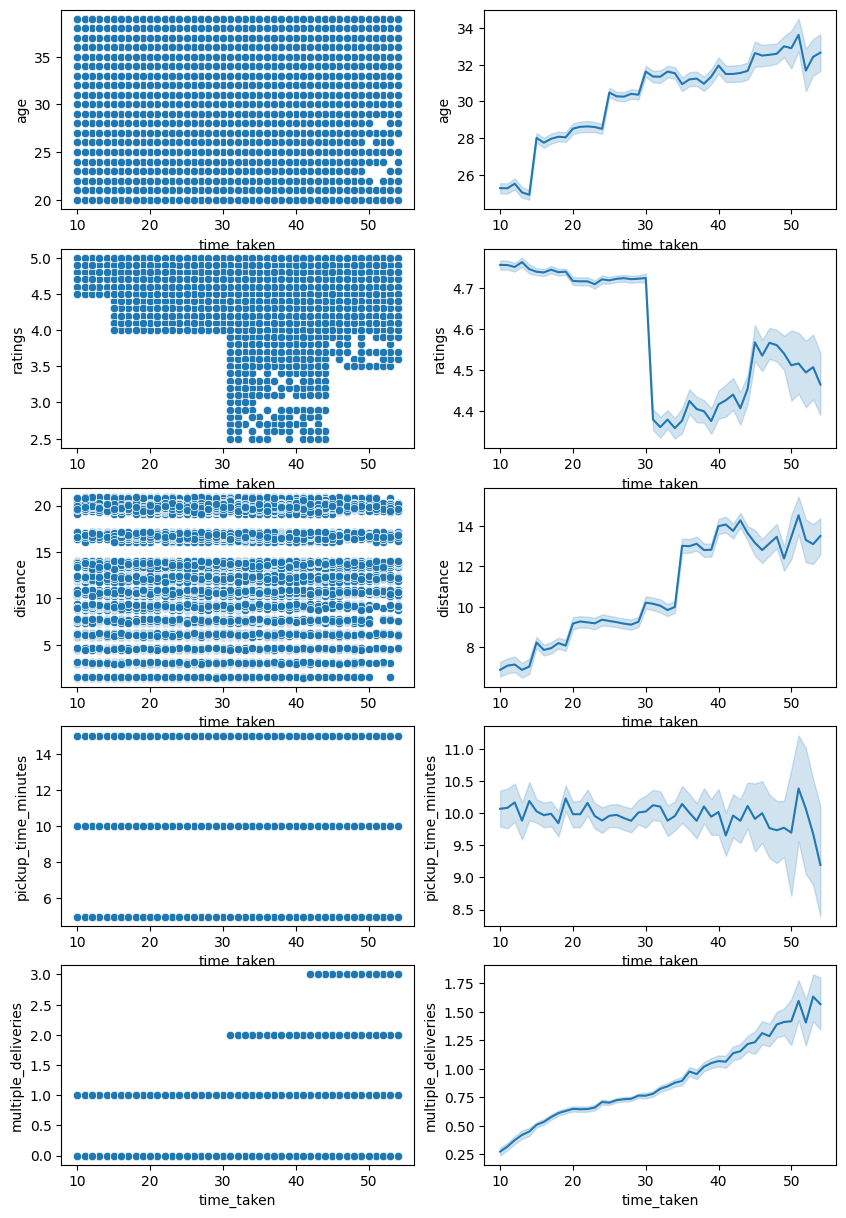

In [10]:
plt.figure(figsize=(10,15))

plt.subplot(5,2,1)
sns.scatterplot(df,x='time_taken',y="age")
plt.subplot(5,2,2)
sns.lineplot(df,x='time_taken',y="age")

plt.subplot(5,2,3)
sns.scatterplot(df,x='time_taken',y="ratings")
plt.subplot(5,2,4)
sns.lineplot(df,x='time_taken',y="ratings")

plt.subplot(5,2,5)
sns.scatterplot(df,x='time_taken',y="distance")
plt.subplot(5,2,6)
sns.lineplot(df,x='time_taken',y="distance")

plt.subplot(5,2,7)
sns.scatterplot(df,x='time_taken',y="pickup_time_minutes")
plt.subplot(5,2,8)
sns.lineplot(df,x='time_taken',y="pickup_time_minutes")

plt.subplot(5,2,9)
sns.scatterplot(df,x='time_taken',y="multiple_deliveries")
plt.subplot(5,2,10)
sns.lineplot(df,x='time_taken',y="multiple_deliveries")

#### categorical vs numerical (time_taken)

<Axes: xlabel='festival', ylabel='time_taken'>

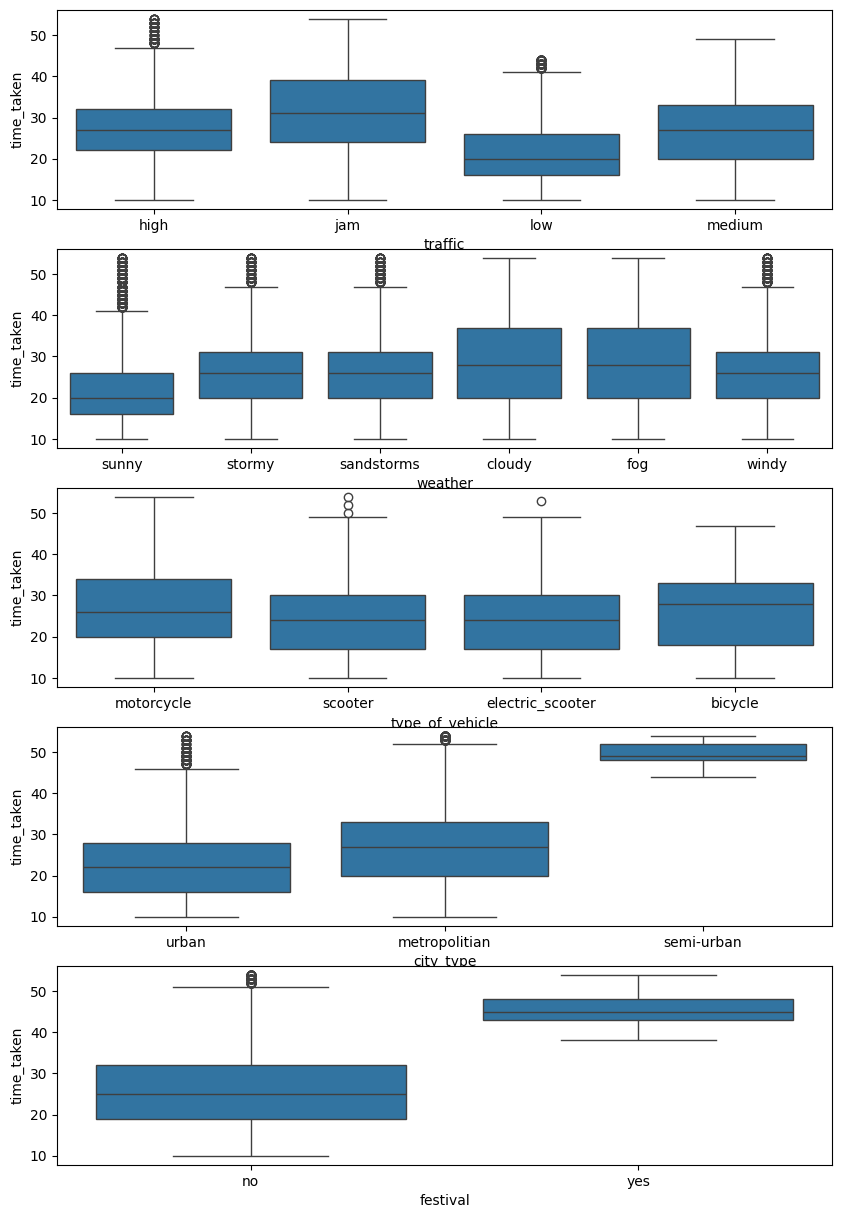

In [11]:
plt.figure(figsize=(10,15))

plt.subplot(5,1,1)
sns.boxplot(df,x='traffic',y="time_taken")

plt.subplot(5,1,2)
sns.boxplot(df,x='weather',y="time_taken")

plt.subplot(5,1,3)
sns.boxplot(df,x='type_of_vehicle',y="time_taken")

plt.subplot(5,1,4)
sns.boxplot(df,x='city_type',y="time_taken")

plt.subplot(5,1,5)
sns.boxplot(df,x='festival',y="time_taken")


### Multi variate analysis

#### correlation Matrix

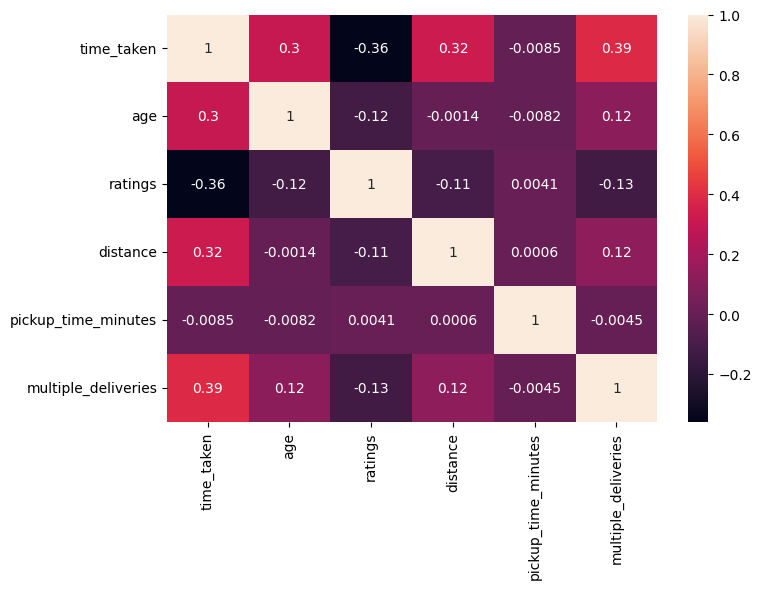

In [12]:
corr = df[["time_taken","age","ratings","distance","pickup_time_minutes","multiple_deliveries"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True)
plt.tight_layout()
plt.show()

#### Traffic + Weather Together

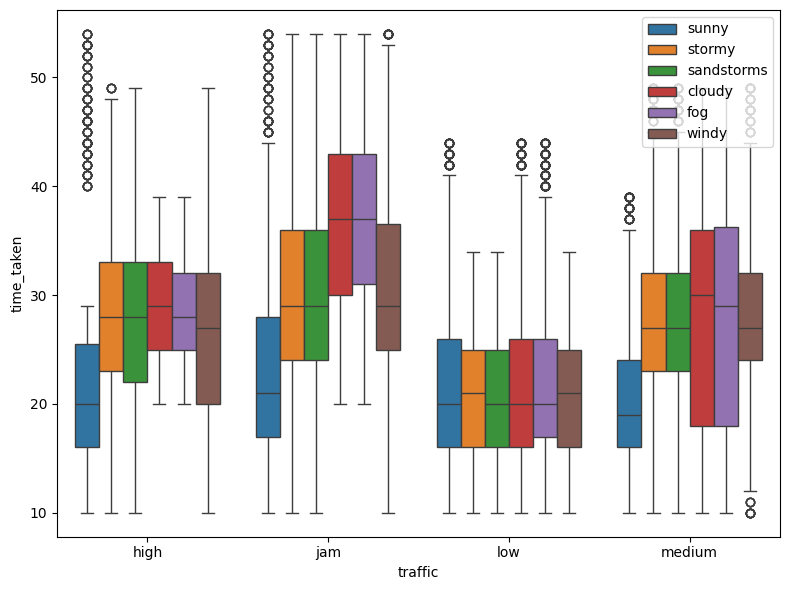

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(df,x = "traffic",y="time_taken",hue="weather",legend='auto')
plt.legend(loc = "upper right")
plt.tight_layout()
plt.show()

In [14]:
pd.pivot_table(
    df, 
    values="time_taken",      
    index="festival", 
    columns="traffic", 
    aggfunc="median"
)

traffic,high,jam,low,medium
festival,,,,
no,27.0,30.0,20.0,26.0
yes,46.0,46.0,42.0,44.0


# 3.Feature Engineering 

### Removing Unnecessary columns 

In [15]:
data = df.drop(columns=['rider_id', 'order_date', 'restaurant_latitude', 'restaurant_longitude', 'delivery_latitude', 'delivery_longitude'])
data

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


In [16]:
data.info() # each columns has its respective data types

<class 'pandas.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  43648 non-null  float64
 1   ratings              43594 non-null  float64
 2   weather              44977 non-null  str    
 3   traffic              44992 non-null  str    
 4   vehicle_condition    45502 non-null  int64  
 5   type_of_order        45502 non-null  str    
 6   type_of_vehicle      45502 non-null  str    
 7   multiple_deliveries  44509 non-null  float64
 8   festival             45274 non-null  str    
 9   city_type            44304 non-null  str    
 10  time_taken           45502 non-null  int64  
 11  city_name            45502 non-null  str    
 12  order_day            45502 non-null  int64  
 13  order_month          45502 non-null  int64  
 14  order_day_of_week    45502 non-null  str    
 15  is_weekend           45502 non-null  int64  
 1

# 4. Data Preprocessing

In [17]:
X = data.drop(columns="time_taken")
y = data["time_taken"]

### Segregating the data with respect to data types

In [18]:
categorical_cols = X.select_dtypes(include='str').columns.tolist()
numeric_cols = X.select_dtypes(exclude='str').columns.tolist()
categorical_cols,numeric_cols

(['weather',
  'traffic',
  'type_of_order',
  'type_of_vehicle',
  'festival',
  'city_type',
  'city_name',
  'order_day_of_week',
  'order_time_of_day'],
 ['age',
  'ratings',
  'vehicle_condition',
  'multiple_deliveries',
  'order_day',
  'order_month',
  'is_weekend',
  'pickup_time_minutes',
  'order_time_hour',
  'distance'])

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer

In [20]:
categorical_transformer = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),
                               ("encoder",OneHotEncoder(handle_unknown="ignore"))])

numeric_transformer = Pipeline([("imputer",SimpleImputer(strategy="median")),
                               ("feature_scaling",StandardScaler()),
                               ("feature_transformation", PowerTransformer(method='yeo-johnson'))])


preprocessing = ColumnTransformer([("numerical",numeric_transformer,numeric_cols),
                                  ("categorical",categorical_transformer,categorical_cols)])
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

### Splitting the Data for ML Training

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 6. Model Building

## Linear Regression

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error,r2_score

In [23]:
lr_model = Pipeline([("preprocessing",preprocessing),
                    ("linear",LinearRegression())])

lr_model.fit(X_train,y_train)
lr_pred = lr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,lr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,lr_pred))
print("R2 Score:", r2_score(y_test,lr_pred))

Mean Absolute Error: 4.949308476165379
Root Mean Square Error: 6.22038357690716
R2 Score: 0.5601100122868862


## KNN Regressor

In [24]:
from sklearn.neighbors import KNeighborsRegressor

In [25]:
knn_model = Pipeline([("preprocessing",preprocessing),
                     ("KNN",KNeighborsRegressor())])
knn_model.fit(X_train,y_train)
knn_pred = knn_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,knn_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,knn_pred))
print("R2 Score:", r2_score(y_test,knn_pred))

Mean Absolute Error: 4.667465113723766
Root Mean Square Error: 5.962815958646223
R2 Score: 0.5957848794087519


## Support Vector Regressor

In [26]:
from sklearn.svm import SVR

In [27]:
svr_model = Pipeline([("preprocessing",preprocessing),
                     ("svr",SVR())])
svr_model.fit(X_train,y_train)
svr_pred = svr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,svr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,svr_pred))
print("R2 Score:", r2_score(y_test,svr_pred))

Mean Absolute Error: 4.0725819166973585
Root Mean Square Error: 5.177242850138188
R2 Score: 0.6952758887704573


## Decision Tree Regressor

In [28]:
from sklearn.tree import DecisionTreeRegressor

In [29]:
dtr_model = Pipeline([("preprocessing",preprocessing),
                     ("DTR",DecisionTreeRegressor())])
dtr_model.fit(X_train,y_train)
dtr_pred = dtr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,dtr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,dtr_pred))
print("R2 Score:", r2_score(y_test,dtr_pred))

Mean Absolute Error: 4.3251291066915725
Root Mean Square Error: 5.728741701765846
R2 Score: 0.626897441344439


## Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rfr_model = Pipeline([("preprocessing",preprocessing),
                     ("random_forest",RandomForestRegressor())])
rfr_model.fit(X_train,y_train)
rfr_pred = rfr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,rfr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,rfr_pred))
print("R2 Score:", r2_score(y_test,rfr_pred))

Mean Absolute Error: 3.242762333809471
Root Mean Square Error: 4.103894179233655
R2 Score: 0.8085294201298069


## Gradient Boost Regresssor

In [32]:
from sklearn.ensemble import GradientBoostingRegressor

In [33]:
gbr_model = Pipeline([("preprocessing",preprocessing),
                     ("gradient_boost",GradientBoostingRegressor())])
gbr_model.fit(X_train,y_train)
gbr_pred = gbr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,gbr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,gbr_pred))
print("R2 Score:", r2_score(y_test,gbr_pred))

Mean Absolute Error: 3.710641100150654
Root Mean Square Error: 4.659011554919497
R2 Score: 0.7532271822176067


In [34]:
from xgboost import XGBRegressor

In [35]:
xgbr_model = Pipeline([("preprocessing",preprocessing),
                      ("xgboost",XGBRegressor())])
xgbr_model.fit(X_train,y_train)
xgbr_pred = xgbr_model.predict(X_test)

print("Mean Absolute Error:", mean_absolute_error(y_test,xgbr_pred))
print("Root Mean Square Error:", root_mean_squared_error(y_test,xgbr_pred))
print("R2 Score:", r2_score(y_test,xgbr_pred))

Mean Absolute Error: 3.264380693435669
Root Mean Square Error: 4.102527141571045
R2 Score: 0.8086569309234619


#### From the observations we can select the random forest model or XGBoost Regressior model which has similar MAE,RMSE and R2 Score

# 7. Cross Validation

In [36]:
from sklearn.model_selection import KFold,cross_val_score

In [38]:
kf = KFold(n_splits=5,shuffle=True,random_state=42)

xgb_crossval = cross_val_score(xgbr_model,X_train,y_train,cv=kf,scoring="r2")

print("xgboost cross validation score",xgb_crossval.mean())

xgboost cross validation score 0.8067020535469055


In [39]:
# Train prediction
y_train_pred_xgb = xgbr_model.predict(X_train)

# Test prediction
y_test_pred_xgb = xgbr_model.predict(X_test)

# R2 Score
train_r2_xgb = r2_score(y_train, y_train_pred_xgb)
test_r2_xgb = r2_score(y_test, y_test_pred_xgb)

print("Train R2:", train_r2_xgb)
print("Test R2:", test_r2_xgb)

train_rmse_xgb = root_mean_squared_error(y_train, y_train_pred_xgb)
test_rmse_xgb = root_mean_squared_error(y_test, y_test_pred_xgb)

print("Train RMSE:", train_rmse_xgb)
print("Test RMSE:", test_rmse_xgb)

Train R2: 0.8642536997795105
Test R2: 0.8086569309234619
Train RMSE: 3.4589102268218994
Test RMSE: 4.102527141571045


# 7. Hyperparameter Tuning 
- to find the optimal paramerters for the model to get highest r2 score
- from all the models the Random Forest and the XGBoost models perform well so hyper tuning them gives the best r2 score

### XGBOOST - GridSearchCV

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    'xgboost__n_estimators': [100, 200, 300],
    'xgboost__max_depth': [4, 6, 7, 8],
    'xgboost__learning_rate': [0.05, 0.1, 0.01],
    }

grid_xgb = GridSearchCV(
    estimator=xgbr_model,
    param_grid=param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)

Best Parameters: {'xgboost__learning_rate': 0.05, 'xgboost__max_depth': 8, 'xgboost__n_estimators': 200}
Best CV Score: 0.8150692462921143


## Final Model

In [43]:
xgb_tuned = Pipeline([('Preprocessing',preprocessing),
                     ("xgboost", XGBRegressor(
                         random_state=23,
                         learning_rate=0.05,
                         max_depth=8,
                         n_estimators=200
                     ))])


xgb_tuned.fit(X_train, y_train)
y_pred = xgb_tuned.predict(X_test)

print("XGBoost (GridSearch Tuned)")
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

XGBoost (GridSearch Tuned)
MSE: 15.946039199829102
RMSE: 3.9932491779327393
R2 Score: 0.8187147378921509


## Testing the model with random/test data

In [46]:
test = pd.DataFrame([{
    'age': 30,
    'ratings': 4.7,
    'weather': 'sunny',
    'traffic': 'high',
    'vehicle_condition': 1,
    'type_of_order': 'meal',
    'type_of_vehicle': 'motorcycle',
    'multiple_deliveries': 1,
    'festival': 'no',
    'city_type': 'urban',
    'city_name': 'BANG',
    'order_day': 15,
    'order_month': 3,
    'order_day_of_week': 'friday',
    'is_weekend': 0,
    'pickup_time_minutes': 10,
    'order_time_hour': 18,
    'order_time_of_day': 'evening',
    'distance': 5.5
}])

# Prediction
y_pred = xgb_tuned.predict(test)

print("Predicted Delivery Time in minutes:", y_pred[0])

Predicted Delivery Time in minutes: 18.404324
